# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [15]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [16]:
corpus = '''
In today's digital world, access to information has become easier than ever before. Students can find answers within seconds, professionals can copy existing work with a few clicks, and advanced tools can generate essays, code, and reports almost instantly. While these technologies have improved productivity and learning, they have also made cheating remarkably easy. The true challenge of the modern era is therefore not whether people have the opportunity to cheat, but whether they choose to act with integrity. Ethics is the foundation of trust in every relationship, whether it exists between friends, teachers and students, employers and employees, or businesses and customers. When people choose honesty even when no one is watching, they build credibility that cannot be bought or copied. Cheating may provide short-term rewards, such as better grades, faster promotions, or financial gain, but these benefits often come at the cost of long-term character and reputation. A person who repeatedly relies on dishonest methods gradually loses confidence in their own abilities because success is no longer earned through genuine effort. Moreover, widespread unethical behavior weakens institutions by reducing fairness and discouraging those who work honestly. In education, cheating prevents real learning and produces graduates who lack the skills they claim to possess. In the workplace, unethical decisions can lead to financial losses, damaged reputations, and even public safety risks. Technology itself is neither good nor bad; it simply amplifies human intentions. Artificial intelligence, the internet, and digital communication can be used to educate, innovate, and solve global problems, or they can be misused for plagiarism, misinformation, and fraud. The responsibility therefore lies with individuals to use these tools wisely. Ethical behavior encourages accountability, respect, and responsibility, qualities that remain valuable regardless of technological progress. As society continues to develop more powerful technologies, the importance of personal integrity only becomes greater. Success achieved through honesty may require more patience and effort, but it creates lasting confidence, meaningful achievements, and the trust of others. In an age where cheating has become easier than ever, choosing to be ethical is not a sign of weakness but a demonstration of true strength and character.
'''
print(corpus)


In today's digital world, access to information has become easier than ever before. Students can find answers within seconds, professionals can copy existing work with a few clicks, and advanced tools can generate essays, code, and reports almost instantly. While these technologies have improved productivity and learning, they have also made cheating remarkably easy. The true challenge of the modern era is therefore not whether people have the opportunity to cheat, but whether they choose to act with integrity. Ethics is the foundation of trust in every relationship, whether it exists between friends, teachers and students, employers and employees, or businesses and customers. When people choose honesty even when no one is watching, they build credibility that cannot be bought or copied. Cheating may provide short-term rewards, such as better grades, faster promotions, or financial gain, but these benefits often come at the cost of long-term character and reputation. A person who repe

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [17]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 232
X shape: (354, 354)
y shape: (354,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [18]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

C:\Users\satya\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [19]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [20]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

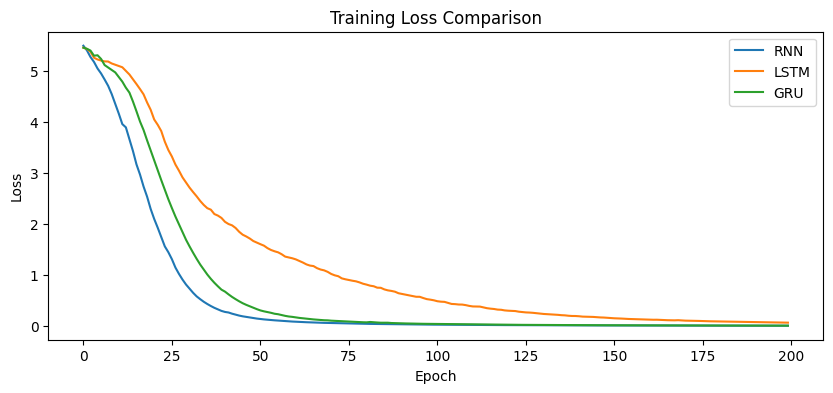

In [21]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [22]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [23]:
print("RNN :", generate_text(rnn_model, "in today's digital world", 10))
print("LSTM:", generate_text(lstm_model, "in today's digital world", 10))
print("GRU :", generate_text(gru_model, "in today's digital world", 10))
print()
print("RNN :", generate_text(rnn_model, "success achieved through", 10))
print("LSTM:", generate_text(lstm_model, "success achieved through", 10))
print("GRU :", generate_text(gru_model, "success achieved through", 10))

RNN : in today's digital world access to information has become easier than ever before students
LSTM: in today's digital world access to information has become easier than ever before students
GRU : in today's digital world access to information has become easier than ever before students

RNN : success achieved through today's digital world access to information has become easier than
LSTM: success achieved through information has become easier than ever before students can find
GRU : success achieved through honesty even when no one is watching they build credibility


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**